# Data Retrieval 

In [99]:
import pandas as pd

permit_df = pd.read_csv("input_data/DOB_Permit_Issuance_20250508.csv", dtype=str)

# Data Clean Up

In [100]:
print(permit_df.head()) 
print("Columns: ", list(permit_df.columns))
print("Number of rows: ", len(permit_df))

         BOROUGH    Bin # House #       Street Name      Job # Job doc. #  \
0      MANHATTAN  1088749       1       MADISON AVE  141008987         01   
1  STATEN ISLAND  5076937      87     BOYLAN STREET  540218539         01   
2  STATEN ISLAND  5001506     217  LAFAYETTE AVENUE  540218575         01   
3  STATEN ISLAND  5067021     170    OAKDALE STREET  540218600         01   
4  STATEN ISLAND  5058036     273         10 STREET  540218628         01   

  Job Type Self_Cert  Block    Lot  ... Owner’s House State  \
0       A3         Y  00853  00002  ...                 NaN   
1       A2         Y  05687  00066  ...                 NaN   
2       A2         Y  00064  00022  ...                 NaN   
3       A2         Y  05260  00001  ...                 NaN   
4       A2         Y  04242  00045  ...                 NaN   

  Owner’s House Zip Code Owner's Phone #           DOBRunDate PERMIT_SI_NO  \
0                    NaN      2125942700  05/11/2022 00:00:00      3905851   
1 

In [101]:
# identify abbreviation for NB
print(permit_df["Job Type"].describe())
print()
print(permit_df["Job Type"].value_counts(dropna=False))

# filter to new buildings
permit_df = permit_df[permit_df["Job Type"] == "NB"]


count     3978666
unique          6
top            A2
freq      2384010
Name: Job Type, dtype: object

Job Type
A2    2384010
NB     568797
A1     432372
A3     413266
DM     102211
SG      78010
Name: count, dtype: int64


In [102]:
# Check for duplicates by checking each row identifier
permit_df = permit_df.drop_duplicates(subset=["PERMIT_SI_NO"])
print("Number of rows after removing duplicates: ", len(permit_df))

Number of rows after removing duplicates:  568797


In [103]:
# view null value counts in the data
num_null_col = permit_df.isnull().sum()
print("Number of null values per column")
print(num_null_col)

Number of null values per column
BOROUGH                                  0
Bin #                                    0
House #                                  0
Street Name                              0
Job #                                    0
Job doc. #                               0
Job Type                                 0
Self_Cert                           197368
Block                                  218
Lot                                    218
Community Board                        593
Zip Code                               361
Bldg Type                             2781
Residential                         109006
Special District 1                  511426
Special District 2                  568772
Work Type                           313426
Permit Status                         2374
Filing Status                            0
Permit Type                              0
Permit Sequence #                        0
Permit Subtype                      419176
Oil Gas              

In [104]:
# view null percentages in the data
percent_null_col = (num_null_col / len(permit_df)) * 100
print("Percent of null values per column")
print(percent_null_col)

Percent of null values per column
BOROUGH                               0.000000
Bin #                                 0.000000
House #                               0.000000
Street Name                           0.000000
Job #                                 0.000000
Job doc. #                            0.000000
Job Type                              0.000000
Self_Cert                            34.699198
Block                                 0.038327
Lot                                   0.038327
Community Board                       0.104255
Zip Code                              0.063467
Bldg Type                             0.488927
Residential                          19.164306
Special District 1                   89.913625
Special District 2                   99.995605
Work Type                            55.103315
Permit Status                         0.417372
Filing Status                         0.000000
Permit Type                           0.000000
Permit Sequence #         

In [105]:
# dropping columns with over 90% missing values to help with performance
drop_cols = percent_null_col[percent_null_col > 90].index
permit_df_dropped = permit_df.drop(columns=drop_cols)

In [106]:
# get formatting for Filing Date
# print(set(permit_df_dropped["Filing Date"]))
# value counts
print(permit_df_dropped[["Filing Date"]].value_counts(dropna=False).head())
print()

# Filing Date seems to granular according to value counts --> getting month/year and year
def get_month_year(date):
    if len(date.split("/")) == 3:
        return f'{date.split("/")[0]}/{date.split("/")[2]}'
    elif len(date.split("-")) == 3:
        return f'{date.split("-")[1]}/{date.split("-")[0]}'
    
def get_year(date):
    if len(date.split("/")) == 3:
        return date.split("/")[2]
    elif len(date.split("-")) == 3:
        return date.split("-")[0]

permit_df_dropped["Filing Date"] = permit_df_dropped["Filing Date"].fillna("")
permit_df_dropped["Filing Date Month/Year"] = permit_df_dropped["Filing Date"].apply(get_month_year)
permit_df_dropped["Filing Date Year"] = permit_df_dropped["Filing Date"].apply(get_year)

# checking value counts
print(permit_df_dropped[["Filing Date Month/Year"]].value_counts(dropna=False).head())
print(permit_df_dropped[["Filing Date Year"]].value_counts(dropna=False).head())

print(permit_df_dropped["Filing Date Month/Year"].head())
print(permit_df_dropped["Filing Date Year"].head())

Filing Date
12/28/2007     316
12/28/2006     316
04/04/2008     307
12/29/2006     297
12/31/2007     296
Name: count, dtype: int64

Filing Date Month/Year
03/2006                   4478
01/2007                   4062
01/2006                   3936
03/2005                   3732
12/2005                   3679
Name: count, dtype: int64
Filing Date Year
2006                36996
2005                36621
2007                33622
2004                32870
2003                27079
Name: count, dtype: int64
5     05/2022
11    06/2020
12    05/2022
13    05/2022
14    05/2022
Name: Filing Date Month/Year, dtype: object
5     2022
11    2020
12    2022
13    2022
14    2022
Name: Filing Date Year, dtype: object


# Analysis

In [107]:
# filtering down to columns for analysis (based on data mentioned in documentation and column descriptions)
permit_df_filtered = permit_df_dropped[["PERMIT_SI_NO", "Job Type", "Work Type", "Permit Type", "Permit Subtype", "Permit Status", "LATITUDE", "LONGITUDE", "COUNCIL_DISTRICT", "CENSUS_TRACT", "Filing Status", "Bldg Type", "Zip Code", "BOROUGH", "Filing Date Month/Year", "Filing Date Year"]]

In [109]:
# initial look into value counts for each column (ie number of inque values)
    # excluding non-categorical, id data, and Job Type since that's been processed
summary_table = permit_df_filtered.drop(columns=["PERMIT_SI_NO", "LONGITUDE", "LATITUDE", "Job Type"]).describe()
summary_table.T.to_csv("permit_summary_table.csv")
print(summary_table)

       Work Type Permit Type Permit Subtype Permit Status COUNCIL_DISTRICT  \
count     255371      568797         149621        566423           565671   
unique         8           5             10             4               51   
top           PL          NB             FN        ISSUED               51   
freq      129115      265343         124206        550781            44419   

       CENSUS_TRACT Filing Status Bldg Type Zip Code BOROUGH  \
count        565671        568797    566016   568436  568797   
unique         1280             2         2      190       5   
top             226       RENEWAL         1    10309  QUEENS   
freq           7592        306747    353425    17098  180759   

       Filing Date Month/Year Filing Date Year  
count                  568796           568796  
unique                    432               37  
top                   03/2006             2006  
freq                     4478            36996  


In [110]:
import matplotlib.pyplot as plt

def create_freq_graph(percentages, title, x_label, y_label, save=False):
    bars = plt.bar(percentages.index, percentages.values)

    # Customize the plot
    plt.xlabel(x_label)
    plt.xticks(rotation=45, ha='right')
    plt.ylabel(y_label)
    plt.title(title)
    plt.ylim(0, 100) 
    # plt.grid(axis='y', linestyle='--')
    if save:
        plt.savefig(f'{"_".join(title.split(" "))}.png', dpi=300, bbox_inches='tight')
    plt.show()


Work Type Work Type
NaN    313426
PL     129115
EQ     126084
SP        111
SD         48
FP          9
FA          2
OT          1
NB          1
Name: count, dtype: int64


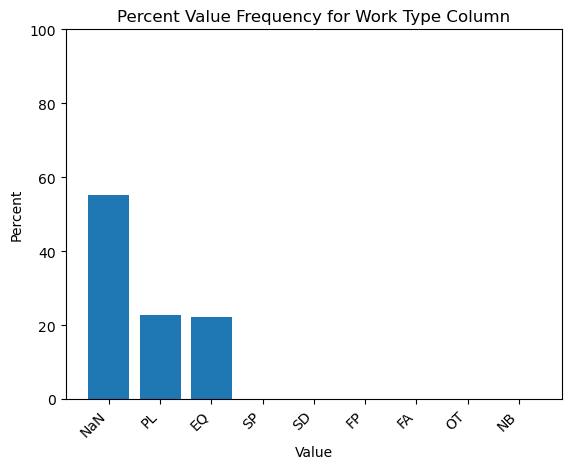


Permit Type Permit Type
NB    265343
PL    129115
EQ    126084
FO     48085
EW       170
Name: count, dtype: int64


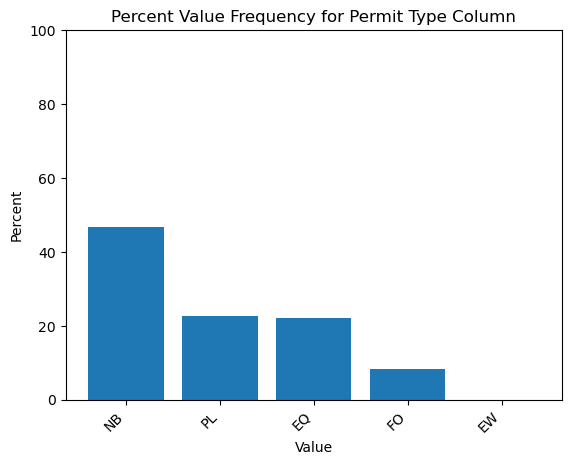


Permit Subtype Permit Subtype
NaN    419176
FN     124206
EA      23367
SH       1626
SP        111
OT        110
SF        104
SD         48
CH         38
FP          9
FA          2
Name: count, dtype: int64


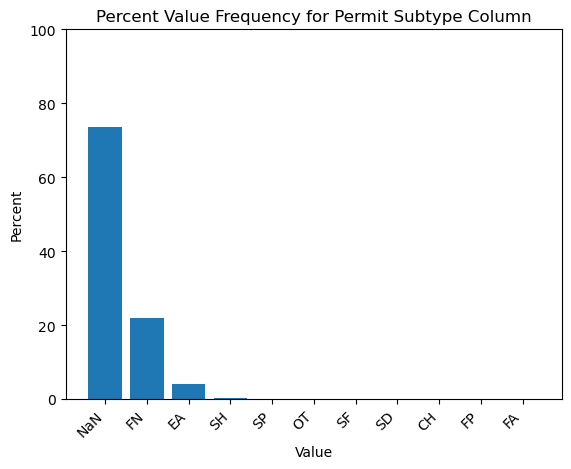


Filing Status Filing Status
RENEWAL    306747
INITIAL    262050
Name: count, dtype: int64


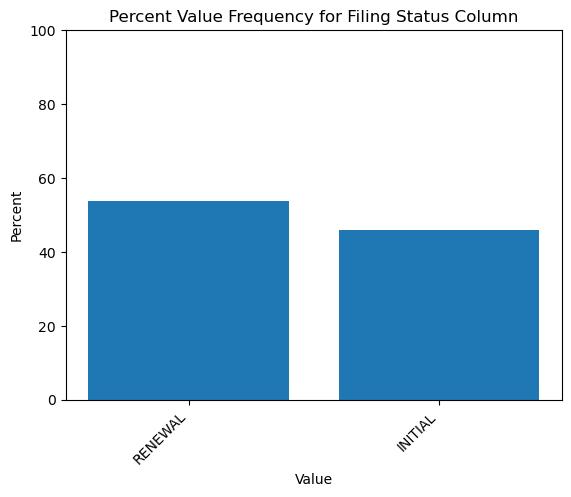


Permit Status Permit Status
ISSUED        550781
RE-ISSUED      13187
IN PROCESS      2454
NaN             2374
REVOKED            1
Name: count, dtype: int64


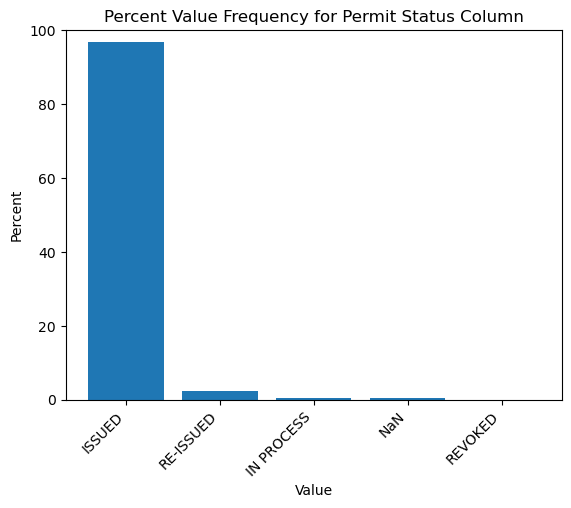

In [ ]:
# most frequent values for highlighted columns in the data description
for col in ["Work Type", "Permit Type", "Permit Subtype", "Filing Status", "Permit Status"]:
    value_counts = permit_df_filtered[col].fillna("NaN").value_counts(dropna=False)
    percentages = permit_df_filtered[col].fillna("NaN").value_counts(dropna=False, normalize=True)  * 100
    print(col, value_counts)
    create_freq_graph(percentages, f'Percent Value Frequency for {col} Column (New Buildings)', 'Value', 'Percent')
    print()

In [112]:
# counts of combinations from permit and job-related columns and the frequency of each column
print('Value counts for New Buildings for "Work Type", "Permit Type", "Permit Subtype"')
print(permit_df_filtered[["Work Type", "Permit Type", "Permit Subtype"]].value_counts(dropna=False))
print()
print('Percentages for New Buildings for "Work Type", "Permit Type", "Permit Subtype"')
print((permit_df_filtered[["Work Type", "Permit Type", "Permit Subtype"]].value_counts(dropna=False, normalize=True) * 100).head())

Value counts for New Buildings for "Work Type", "Permit Type", "Permit Subtype"
Work Type  Permit Type  Permit Subtype
NaN        NB           NaN               265341
PL         PL           NaN               129115
EQ         EQ           FN                124206
NaN        FO           NaN                24718
                        EA                 23367
EQ         EQ           SH                  1626
SP         EW           SP                   111
EQ         EQ           OT                   110
                        SF                   104
SD         EW           SD                    48
EQ         EQ           CH                    38
FP         EW           FP                     9
FA         EW           FA                     2
NB         NB           NaN                    1
OT         NB           NaN                    1
Name: count, dtype: int64

Percentages for New Buildings for "Work Type", "Permit Type", "Permit Subtype"
Work Type  Permit Type  Permit Subtype
N

BOROUGH BOROUGH
QUEENS           180759
BROOKLYN         175058
STATEN ISLAND    100769
BRONX             75409
MANHATTAN         36802
Name: count, dtype: int64


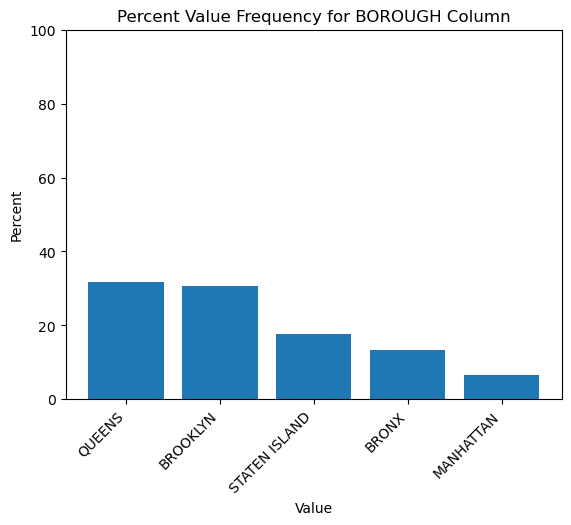


Bldg Type Bldg Type
1      353425
2      212591
NaN      2781
Name: count, dtype: int64


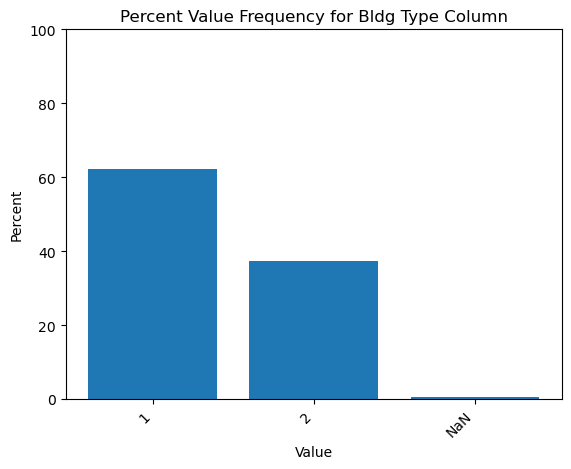


Filing Date Year Filing Date Year
2006    36996
2005    36621
2007    33622
2004    32870
2003    27079
2008    25920
2002    22821
2017    21197
2001    20575
2015    20183
2016    20169
2018    19981
2009    19453
2019    18652
2014    17368
2000    17056
2010    15720
2013    15118
2020    14576
2021    13861
1999    13669
2011    13637
2012    13531
1998    10679
2022    10158
1997     8841
1996     8576
1995     7242
2023     6340
1994     6265
1993     5977
1992     4877
2024     4084
1991     2962
2025     1152
1990      911
1989       57
NaN         1
Name: count, dtype: int64


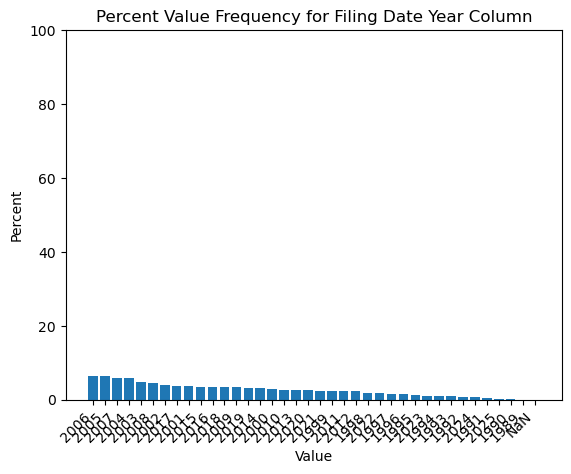

In [113]:
# value counts for other interesting columns
for col in ["BOROUGH", "Bldg Type", "Filing Date Year"]:
    value_counts = permit_df_filtered[col].fillna("NaN").value_counts(dropna=False)
    percentages = permit_df_filtered[col].fillna("NaN").value_counts(dropna=False, normalize=True)  * 100
    print(col, value_counts)
    create_freq_graph(percentages, f'Percent Value Frequency for {col} Column', 'Value', 'Percent')
    print()

/var/folders/ds/dbv3h1h93pjgyk54lfs80x4w0000gn/T/ipykernel_12801/1377751346.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  permit_df_filtered['Filing Date Year datetime'] = pd.to_datetime(permit_df_filtered['Filing Date Year'])


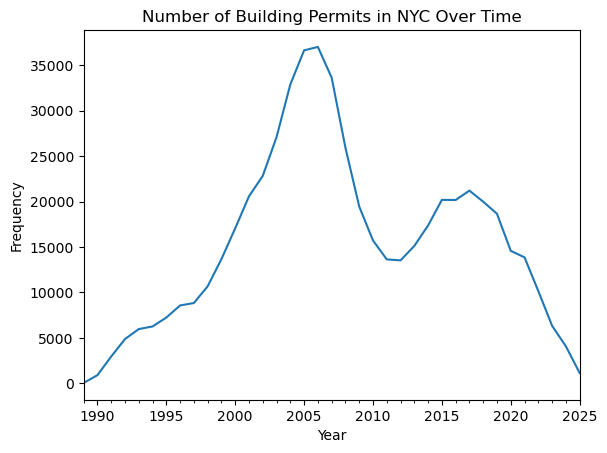

In [ ]:
# plot for filing date for new buildigns by month and year
permit_df_filtered['Filing Date Year datetime'] = pd.to_datetime(permit_df_filtered['Filing Date Year'])
value_counts = permit_df_filtered['Filing Date Year datetime'].value_counts().sort_index()
value_counts.plot(kind='line')
    
# Customize the plot (optional)
plt.title('Number of New Building Permits in NYC Over Time')
plt.xlabel('Year')
plt.ylabel('Frequency')

plt.savefig('building_permit_freq_over_time.png', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()


/var/folders/ds/dbv3h1h93pjgyk54lfs80x4w0000gn/T/ipykernel_12801/4279094712.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  permit_df_filtered['Filing Date Month/Year datetime'] = pd.to_datetime(permit_df_filtered['Filing Date Month/Year'])
/var/folders/ds/dbv3h1h93pjgyk54lfs80x4w0000gn/T/ipykernel_12801/4279094712.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  permit_df_filtered['Filing Date Month/Year datetime'] = pd.to_datetime(permit_df_filtered['Filing Date Month/Year'])


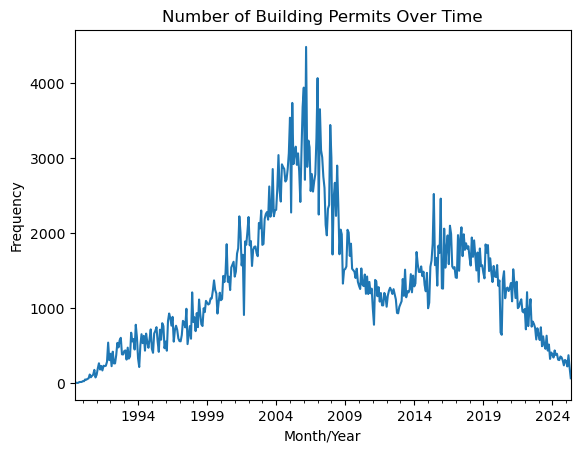

In [115]:
# plot for filing date for new buildigns by year
permit_df_filtered['Filing Date Month/Year datetime'] = pd.to_datetime(permit_df_filtered['Filing Date Month/Year'])
value_counts = permit_df_filtered['Filing Date Month/Year datetime'].value_counts().sort_index()
value_counts.plot(kind='line')
    
plt.title('Number of Building Permits Over Time')
plt.xlabel('Month/Year')
plt.ylabel('Frequency')

plt.show()

# Processing and cleaning historic districts

In [116]:
# getting data
historic_df = pd.read_csv("input_data/Historic_Districts_20250508.csv", dtype=str)

In [117]:
# getting overview of historic data
print(historic_df.head())
print()
print("Columns: ", list(historic_df.columns))
print()
print("Number of rows: ", len(historic_df))
print()
print(historic_df.describe())

                                            the_geom BOROUGH LP_NUMBER  \
0  MULTIPOLYGON (((-73.78070476564865 40.79368791...      QN  LP-02040   
1  MULTIPOLYGON (((-73.9545180987722 40.781621828...      MN  LP-01985   
2  MULTIPOLYGON (((-73.9944118740248 40.725865366...      MN  LP-02287   
3  MULTIPOLYGON (((-73.95607477556511 40.67451198...      BK  LP-02446   
4  MULTIPOLYGON (((-73.98858964616774 40.73001207...      MN  LP-00250   

  CURRENT_                                  AREA_NAME EXTENSION  STATUS_OF_  \
0      Yes              Fort Totten Historic District        No  DESIGNATED   
1      Yes  Hardenbergh/Rhinelander Historic District        No  DESIGNATED   
2      Yes           NoHo Historic District Extension       Yes  DESIGNATED   
3      Yes               Park Place Historic District        No  DESIGNATED   
4      Yes               St. Mark's Historic District        No  DESIGNATED   

   LAST_ACTIO BOUNDARY_N  PUBLIC_HEA OTHER_HEAR     DESDATE     CALDATE  \
0  DE

In [118]:
# creating geodataframe for historic data
import shapely
import geopandas as gpd

historic_df['the_geom'] = historic_df['the_geom'].apply(shapely.wkt.loads)
historic_gdf = gpd.GeoDataFrame(historic_df, geometry='the_geom', crs="EPSG:4326")


In [ ]:
# converting permit data into a geodataframe
geometry = gpd.points_from_xy(permit_df_filtered["LONGITUDE"], permit_df_filtered["LATITUDE"], crs="EPSG:4326")
permit_df_filtered["permit_geometry"] = geometry
permit_gdf = gpd.GeoDataFrame(permit_df_filtered, geometry='permit_geometry')


/var/folders/ds/dbv3h1h93pjgyk54lfs80x4w0000gn/T/ipykernel_12801/3878302790.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  permit_df_filtered["permit_geometry"] = geometry


In [120]:
# spatial join
merged_df = gpd.sjoin(permit_gdf, historic_gdf, how='left', predicate="within")
merged_df["AREA_NAME"] = merged_df["AREA_NAME"].fillna("Not in historic district")
print("merged_df columns: ", merged_df.columns)

merged_df columns:  Index(['PERMIT_SI_NO', 'Job Type', 'Work Type', 'Permit Type',
       'Permit Subtype', 'Permit Status', 'LATITUDE', 'LONGITUDE',
       'COUNCIL_DISTRICT', 'CENSUS_TRACT', 'Filing Status', 'Bldg Type',
       'Zip Code', 'BOROUGH_left', 'Filing Date Month/Year',
       'Filing Date Year', 'Filing Date Year datetime',
       'Filing Date Month/Year datetime', 'permit_geometry', 'index_right',
       'BOROUGH_right', 'LP_NUMBER', 'CURRENT_', 'AREA_NAME', 'EXTENSION',
       'STATUS_OF_', 'LAST_ACTIO', 'BOUNDARY_N', 'PUBLIC_HEA', 'OTHER_HEAR',
       'DESDATE', 'CALDATE', 'Shape_Leng', 'Shape_Area'],
      dtype='object')


In [ ]:
# value counts and percentages
area_value_counts = merged_df["AREA_NAME"].value_counts(dropna=False)
area_percentage = merged_df["AREA_NAME"].value_counts(dropna=False, normalize=True) * 100
print(area_value_counts)
print()
print(area_percentage)

AREA_NAME
Not in historic district                                 564193
SoHo-Cast Iron Historic District                            342
Ladies' Mile Historic District                              304
Fort Greene Historic District                               223
Douglaston Historic District                                217
                                                          ...  
St. Nicholas Historic District                                4
St. Paul's Avenue-Stapleton Heights Historic District         3
Fiske Terrace-Midwood Park Historic District                  2
Prospect Park South Historic District                         1
Riverdale Historic District                                   1
Name: count, Length: 74, dtype: int64

AREA_NAME
Not in historic district                                 99.190572
SoHo-Cast Iron Historic District                          0.060127
Ladies' Mile Historic District                            0.053446
Fort Greene Historic District       

AREA_NAME
SoHo-Cast Iron Historic District                         342
Ladies' Mile Historic District                           304
Fort Greene Historic District                            223
Douglaston Historic District                             217
Cobble Hill Historic District                            200
                                                        ... 
St. Nicholas Historic District                             4
St. Paul's Avenue-Stapleton Heights Historic District      3
Fiske Terrace-Midwood Park Historic District               2
Riverdale Historic District                                1
Prospect Park South Historic District                      1
Name: count, Length: 73, dtype: int64

AREA_NAME
SoHo-Cast Iron Historic District                                 7.428323
Ladies' Mile Historic District                                   6.602954
Fort Greene Historic District                                    4.843614
Douglaston Historic District                    

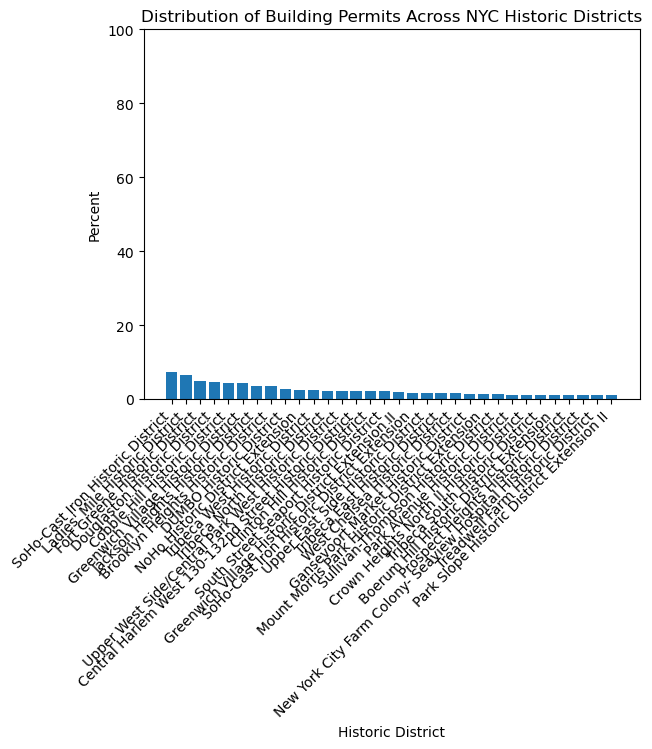

In [ ]:
# filtering out building permits that are not in historic districts for value counts and percentages
area_value_counts = merged_df[merged_df["AREA_NAME"] != "Not in historic district"]["AREA_NAME"].value_counts(dropna=False)
area_percentage = merged_df[merged_df["AREA_NAME"] != "Not in historic district"]["AREA_NAME"].value_counts(dropna=False, normalize=True) * 100
print(area_value_counts)
print()
print(area_percentage[area_percentage > 1])
create_freq_graph(area_percentage[area_percentage > 1], "Distribution of Building Permits Across NYC Historic Districts", "Historic District", "Percent", save=True)

In [123]:
# Historic districts that don't have any building permits in them
print(historic_gdf[~historic_gdf["AREA_NAME"].isin(area_percentage.index)]["AREA_NAME"])

0                       Fort Totten Historic District
1           Hardenbergh/Rhinelander Historic District
3                        Park Place Historic District
4                        St. Mark's Historic District
5              St. Mark's Historic District Extension
                            ...                      
150                East 25th Street Historic District
152    Cambria Heights-227th Street Historic District
153    Cambria Heights-222nd Street Historic District
154                Melrose Parkside Historic District
155                   Linden Street Historic District
Name: AREA_NAME, Length: 84, dtype: object


In [125]:
# summary stats for building permits in historical districts
merged_df_summary_table = merged_df[merged_df["AREA_NAME"] != "Not in historic district"][['Work Type', 'Permit Type', 'Permit Subtype', 'Permit Status', 'Bldg Type', 'BOROUGH_left', 'AREA_NAME', 'Filing Date Month/Year', 'Filing Date Year']].describe()
merged_df_summary_table.T.to_csv("historic_permit_summary_table.csv")
print(merged_df_summary_table)

       Work Type Permit Type Permit Subtype Permit Status Bldg Type  \
count       2020        4604           1552          4585      4583   
unique         4           5              6             3         2   
top           EQ          NB             FN        ISSUED         2   
freq        1210        1861           1196          4355      3305   

       BOROUGH_left                         AREA_NAME Filing Date Month/Year  \
count          4604                              4604                   4604   
unique            5                                73                    376   
top       MANHATTAN  SoHo-Cast Iron Historic District                10/2013   
freq           2619                               342                     50   

       Filing Date Year  
count              4604  
unique               36  
top                2016  
freq                247  


In [126]:
# keeping relevant columns
merged_df = merged_df[['PERMIT_SI_NO', 'Job Type', 'Work Type', 'Permit Type',
       'Permit Subtype', 'Permit Status', 'LATITUDE', 'LONGITUDE',
       'COUNCIL_DISTRICT', 'CENSUS_TRACT', 'Filing Status', 'Bldg Type',
       'Zip Code', 'BOROUGH_left', 'Filing Date Month/Year',
       'Filing Date Year', 'permit_geometry', 'AREA_NAME']]

merged_df = merged_df.rename(columns={"BOROUGH_left": "BOROUGH"})

In [127]:
# save to CSV
merged_df.to_csv("cleaned_dob_permit_issuance.csv", index=False)

In [128]:
# save to shape file
merged_df.to_file("permit_issuance.shp")

/var/folders/ds/dbv3h1h93pjgyk54lfs80x4w0000gn/T/ipykernel_12801/1746143904.py:1: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  merged_df.to_file("output_data/shapes/permit_issuance.shp")
/Users/jasmine/miniconda3/envs/conda-env/lib/python3.13/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'PERMIT_SI_NO' to 'PERMIT_SI_'
  ogr_write(
/Users/jasmine/miniconda3/envs/conda-env/lib/python3.13/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'Permit Type' to 'Permit Typ'
  ogr_write(
/Users/jasmine/miniconda3/envs/conda-env/lib/python3.13/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'Permit Subtype' to 'Permit Sub'
  ogr_write(
/Users/jasmine/miniconda3/envs/conda-env/lib/python3.13/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'Permit Status' to 'Permit Sta'
  ogr_write(
/Users/jasmine/minicon